In [1]:
import sympy
from sympy import symbols, sin, cos
from sympy import Matrix, nsolve
from sympy.parsing.sympy_parser import parse_expr
from itertools import product

import multiprocessing
import os
import time
from tqdm import tqdm

import os
os.chdir("//home//rydpi5")

from expctl.servers.servoaligner.solver_plotter import Optical_system_solver, Mirror, Lens

import numpy as np
import matplotlib.pyplot as plt
import time,pickle
from expctl.servers.servoaligner.scservo_sdk import *                    # Uses SCServo SDK library
from expctl.servers.servoaligner.pts_iterator import pts_iterator
import logging

from smbus2 import SMBus,i2c_msg
import MCP342x

logging.basicConfig(
    level=logging.INFO,  # Set the logging level to DEBUG
    # level= logging.DEBUG,|
    format='%(asctime)s - %(levelname)s - %(message)s'
)

from expctl.servers.servoaligner.servodriver import Servoset
from expctl.servers.servoaligner.servo_util import create_zigzag_X, format_para,a2p,r2nd,r2nr,ndmodr,nrselr,nrmodr,nraddr,compose_para
from expctl.servers.servoaligner.fit_gaussian import gaussian_2d,gaussian_2d_smooth_heaviside,fit_and_plot,fit_gaussian_2d,fit_gaussian_2d_smooth_heaviside,fit_and_plot_smooth_heaviside,popt_get_mu_cov,statistics_skewness
from expctl.servers.servoaligner.motor_scan import motor_1d_scan,motor_2d_scan
from expctl.servers.servoaligner.servo_const import A_X_XDOT_MASK,A_Y_YDOT_MASK,A_X_Y_MASK,A_XDOT_YDOT_MASK,A_POS_ALL_MASK,B_X_XDOT_MASK,B_Y_YDOT_MASK,B_X_Y_MASK,B_XDOT_YDOT_MASK,B_POS_ALL_MASK,POS_ALL_MASK, posmask2str
#from expctl.servers.servoaligner.pd import MCP3424_fiber
from expctl.servers.servoaligner.step_optimize import step_optimize

In [2]:
servos = Servoset(board_id=0,servo_channel_list=[0,1,2,3,4,5,6,7])

i2cbus = SMBus(1)
MCP3424_fiber=MCP342x.MCP342x(i2cbus, 0x68, device='MCP3424', channel=0, gain=1, resolution=12, continuous_mode=False, scale_factor=1.0, offset=0.0)

2025-03-04 15:44:08,853 - INFO - The device /dev/ttyUSB0 is not available, try next ...
2025-03-04 15:44:08,858 - INFO - Succeeded to open the port
2025-03-04 15:44:08,863 - INFO - Succeeded to change the baudrate
2025-03-04 15:44:08,869 - INFO - Servo 1x: SCServo acc set!
2025-03-04 15:44:08,874 - INFO - Servo 1x: SCServo speed set!
2025-03-04 15:44:08,879 - INFO - Servo 1x: SCServo acc set!
2025-03-04 15:44:08,884 - INFO - Servo 1x: SCServo speed set!
2025-03-04 15:44:08,894 - INFO - Servo 1y: SCServo acc set!
2025-03-04 15:44:08,899 - INFO - Servo 1y: SCServo speed set!
2025-03-04 15:44:08,904 - INFO - Servo 1y: SCServo acc set!
2025-03-04 15:44:08,909 - INFO - Servo 1y: SCServo speed set!
2025-03-04 15:44:08,918 - INFO - Servo 2x: SCServo acc set!
2025-03-04 15:44:08,923 - INFO - Servo 2x: SCServo speed set!
2025-03-04 15:44:08,928 - INFO - Servo 2x: SCServo acc set!
2025-03-04 15:44:08,933 - INFO - Servo 2x: SCServo speed set!
2025-03-04 15:44:08,943 - INFO - Servo 2y: SCServo acc

[Errno 2] could not open port /dev/ttyUSB0: [Errno 2] No such file or directory: '/dev/ttyUSB0'


2025-03-04 15:44:09,059 - INFO - loading position from disk
2025-03-04 15:44:09,060 - INFO - Loaded, the positions are: 
Servo 1x: -0.52734375 deg	Servo 1y: -0.52734375 deg	Servo 2x: -0.439453125 deg	Servo 2y: -0.52734375 deg	Servo 3x: 0.0 deg	Servo 3y: 0.0 deg	Servo 4x: -0.17578125 deg	Servo 4y: -0.87890625 deg	


In [3]:
print(MCP3424_fiber.convert_and_read())

1.49


In [ ]:
# Combine them into a single Dataset
ds = xr.Dataset({
    'data1': data_array1,
    'data2': data_array2
})

In [4]:
servos.home()
print(MCP3424_fiber.convert_and_read())

2025-03-04 15:44:13,707 - INFO - going home


1.49


In [4]:
# current_dir=os.path.dirname(__file__)
# file_path=os.path.join(current_dir, "angles0303.npz")
file_path="angles0303.npz"
with np.load(file_path) as data:
    result=data['result']

In [6]:
data_list=[]
for i in tqdm(range(len(result))):
    servos.set_angle(result[i])
    data_list.append(MCP3424_fiber.convert_and_read())

servos.home()
print(MCP3424_fiber.convert_and_read())

  0%|          | 0/36 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:49<00:00,  1.38s/it]
2025-03-04 10:24:02,551 - INFO - going home


1.489


NameError: name 'x_array' is not defined

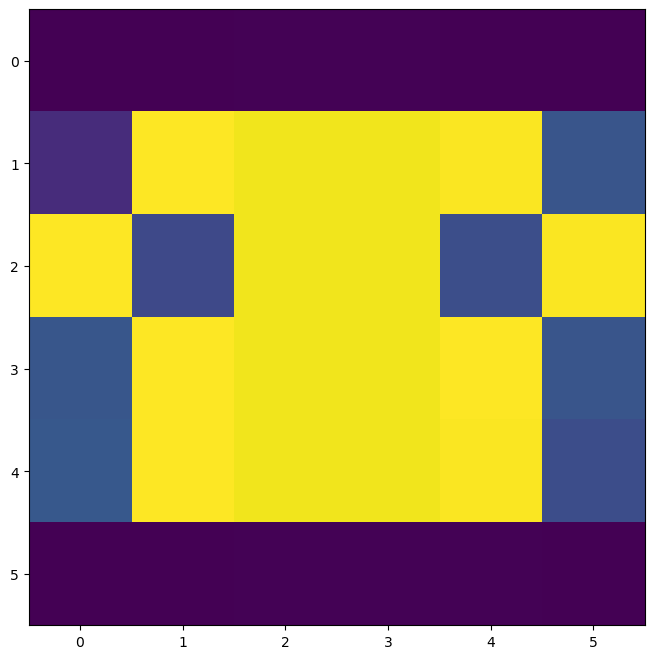

In [ ]:
data_list=np.reshape(data_list, (N_x,N_y))

plt.figure(figsize=(8,8))
plt.imshow(data_list)
plt.xticks(np.arange(N_x)[::2],np.round(1e6*x_array,1)[::2])
plt.yticks(np.arange(N_y)[::2],np.round(1e6*y_array,1)[::2])
plt.colorbar()
plt.show()

In [ ]:
servos.set_zero()

In [ ]:
servos.torques_disable()

In [ ]:
servos.torques_disable()